# 01 EDA — ウクライナ侵攻と世界資源価格・物価変動

**本分析は探索的分析（EDA）および記述的分析のみである。因果推論・仮説検証は対象外。**

PROPOSAL.md Sec 4.4 に事前登録した5つの可視化軸のみを実施する。

| 軸 | 内容 |
|---|---|
| V1 | 資源価格（原油・小麦・天然ガス）月次推移 |
| V2 | 侵攻前後の価格変化率（2022-02 基準） |
| V3 | 各国 CPI 前年同月比の時系列推移 |
| V4 | ピーク月（2022-06）における各国 CPI 水準の比較 |
| V5 | FAO 食料価格指数の時系列推移（サブ指数含む） |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import japanize_matplotlib  # noqa: F401
import json
from pathlib import Path

# パス設定
BASE = Path("..") / "data" / "raw"
FIG_DIR = Path("..") / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 侵攻日
INVASION_DATE = pd.Timestamp("2022-02-24")
INVASION_MONTH = pd.Period("2022-02", freq="M")

# グラフスタイル（set_theme後にフォントを明示 — seabornのrcコンテキストでArialに戻るのを防ぐ）
sns.set_theme(
    style="whitegrid",
    palette="tab10",
    rc={"font.family": "IPAexGothic"},
)
plt.rcParams["figure.dpi"] = 120


## 1. データ読み込みと基本確認

In [2]:
# --- World Bank Pink Sheet ---
_ps_raw = pd.read_excel(
    BASE / "pinksheet_monthly.xlsx",
    sheet_name="Monthly Prices",
    header=None,
)
# 行4=列名、行5=単位、行6以降=データ
_ps_headers = _ps_raw.iloc[4]
_ps_units = _ps_raw.iloc[5]
ps = _ps_raw.iloc[6:].copy()
ps.columns = range(len(ps.columns))
ps = ps.rename(columns={0: "date"})

# 必要列だけ抜く: Brent(2), Natural gas Europe(8), Wheat US HRW(37)
ps = ps[["date", 2, 8, 37]].copy()
ps.columns = ["date", "brent_usd_bbl", "gas_europe_usd_mmbtu", "wheat_hrw_usd_mt"]
ps["date"] = pd.PeriodIndex(ps["date"].str.replace("M", "-"), freq="M")
ps = ps[ps["date"].between(pd.Period("2020-01", "M"), pd.Period("2023-12", "M"))]
ps = ps.replace("…", float("nan"))
for c in ["brent_usd_bbl", "gas_europe_usd_mmbtu", "wheat_hrw_usd_mt"]:
    ps[c] = pd.to_numeric(ps[c], errors="coerce")
ps = ps.reset_index(drop=True)

print("Pink Sheet:", ps.shape)
print(ps.describe().round(1))

Pink Sheet: (48, 4)
       brent_usd_bbl  gas_europe_usd_mmbtu  wheat_hrw_usd_mt
count           48.0                  48.0              48.0
mean            73.8                  18.2             329.3
std             23.2                  16.2              81.0
min             23.3                   1.6             198.4
25%             60.2                   6.1             273.1
50%             76.8                  12.0             320.2
75%             87.2                  28.5             380.9
max            120.1                  70.0             522.3


In [3]:
# --- FAO Food Price Index ---
fao = pd.read_csv(BASE / "fao_food_price_index.csv", skiprows=2)
fao = fao.rename(columns={
    "Date": "date",
    "Food Price Index": "food",
    "Meat": "meat",
    "Dairy": "dairy",
    "Cereals": "cereals",
    "Oils": "oils",
    "Sugar": "sugar",
})
fao = fao[["date", "food", "meat", "dairy", "cereals", "oils", "sugar"]].dropna(subset=["date"])
fao["date"] = pd.PeriodIndex(fao["date"], freq="M")
fao = fao[fao["date"].between(pd.Period("2020-01", "M"), pd.Period("2023-12", "M"))]
for c in ["food", "meat", "dairy", "cereals", "oils", "sugar"]:
    fao[c] = pd.to_numeric(fao[c], errors="coerce")
fao = fao.reset_index(drop=True)

print("FAO:", fao.shape)
print(fao.describe().round(1))

FAO: (48, 7)
        food   meat  dairy  cereals   oils  sugar
count   48.0   48.0   48.0     48.0   48.0   48.0
mean   123.2  108.8  123.7    130.0  144.6  112.1
std     18.1    9.9   18.5     20.3   40.5   25.5
min     91.2   91.2   94.5     97.3   77.8   63.2
25%    112.2  100.2  110.5    119.8  119.7   93.5
50%    124.4  111.8  119.2    128.0  139.6  112.8
75%    134.1  114.9  140.2    145.4  166.6  121.3
max    160.2  125.4  158.2    173.5  251.8  162.7


In [4]:
# --- OECD CPI (月次 10カ国) ---
oecd = pd.read_csv(BASE / "oecd_cpi_monthly.csv")
oecd = oecd[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]].copy()
oecd.columns = ["country", "date", "cpi_yoy"]
oecd["date"] = pd.PeriodIndex(oecd["date"], freq="M")
oecd["cpi_yoy"] = pd.to_numeric(oecd["cpi_yoy"], errors="coerce")

# AUS 四半期 (四半期末月に月次として配置、分析上の注記あり)
aus = pd.read_csv(BASE / "oecd_cpi_aus_quarterly.csv")
aus = aus[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]].copy()
aus.columns = ["country", "date", "cpi_yoy"]
# 四半期を末月に変換: 2022-Q1 → 2022-03
aus["date"] = aus["date"].apply(
    lambda q: pd.Period(q, freq="Q").to_timestamp(how="end").to_period("M")
)
aus["cpi_yoy"] = pd.to_numeric(aus["cpi_yoy"], errors="coerce")

cpi_oecd = pd.concat([oecd, aus], ignore_index=True)
print("OECD CPI 国一覧:", sorted(cpi_oecd["country"].unique()))
print("期間:", cpi_oecd["date"].min(), "〜", cpi_oecd["date"].max())
print("欠損:", cpi_oecd["cpi_yoy"].isna().sum(), "件")

OECD CPI 国一覧: ['AUS', 'DEU', 'FRA', 'GBR', 'ITA', 'JPN', 'KOR', 'POL', 'TUR', 'USA']
期間: 2020-01 〜 2023-12
欠損: 0 件


In [5]:
# --- IMF CPI (年次 OECD非加盟5カ国) ---
with open(BASE / "imf_cpi_annual.json") as f:
    imf_raw = json.load(f)

imf_rows = []
for country, years in imf_raw["values"]["PCPIPCH"].items():
    for year, val in years.items():
        if 2020 <= int(year) <= 2023 and val is not None:
            imf_rows.append({"country": country, "year": int(year), "cpi_yoy": val})
imf = pd.DataFrame(imf_rows)
print("IMF CPI:")
print(imf.pivot(index="year", columns="country", values="cpi_yoy").round(1))

IMF CPI:
country  CHN   EGY  IND   NGA  SAU
year                              
2020     2.5   5.7  6.2  13.2  3.4
2021     0.9   4.5  5.5  17.0  3.1
2022     2.0   8.5  6.7  18.8  2.5
2023     0.2  24.4  5.4  24.7  2.3


## V1: 資源価格（原油・小麦・天然ガス）月次推移

各指標を正規化して1グラフに重ねる（単位が異なるため、2020-01=100 に基準化）。

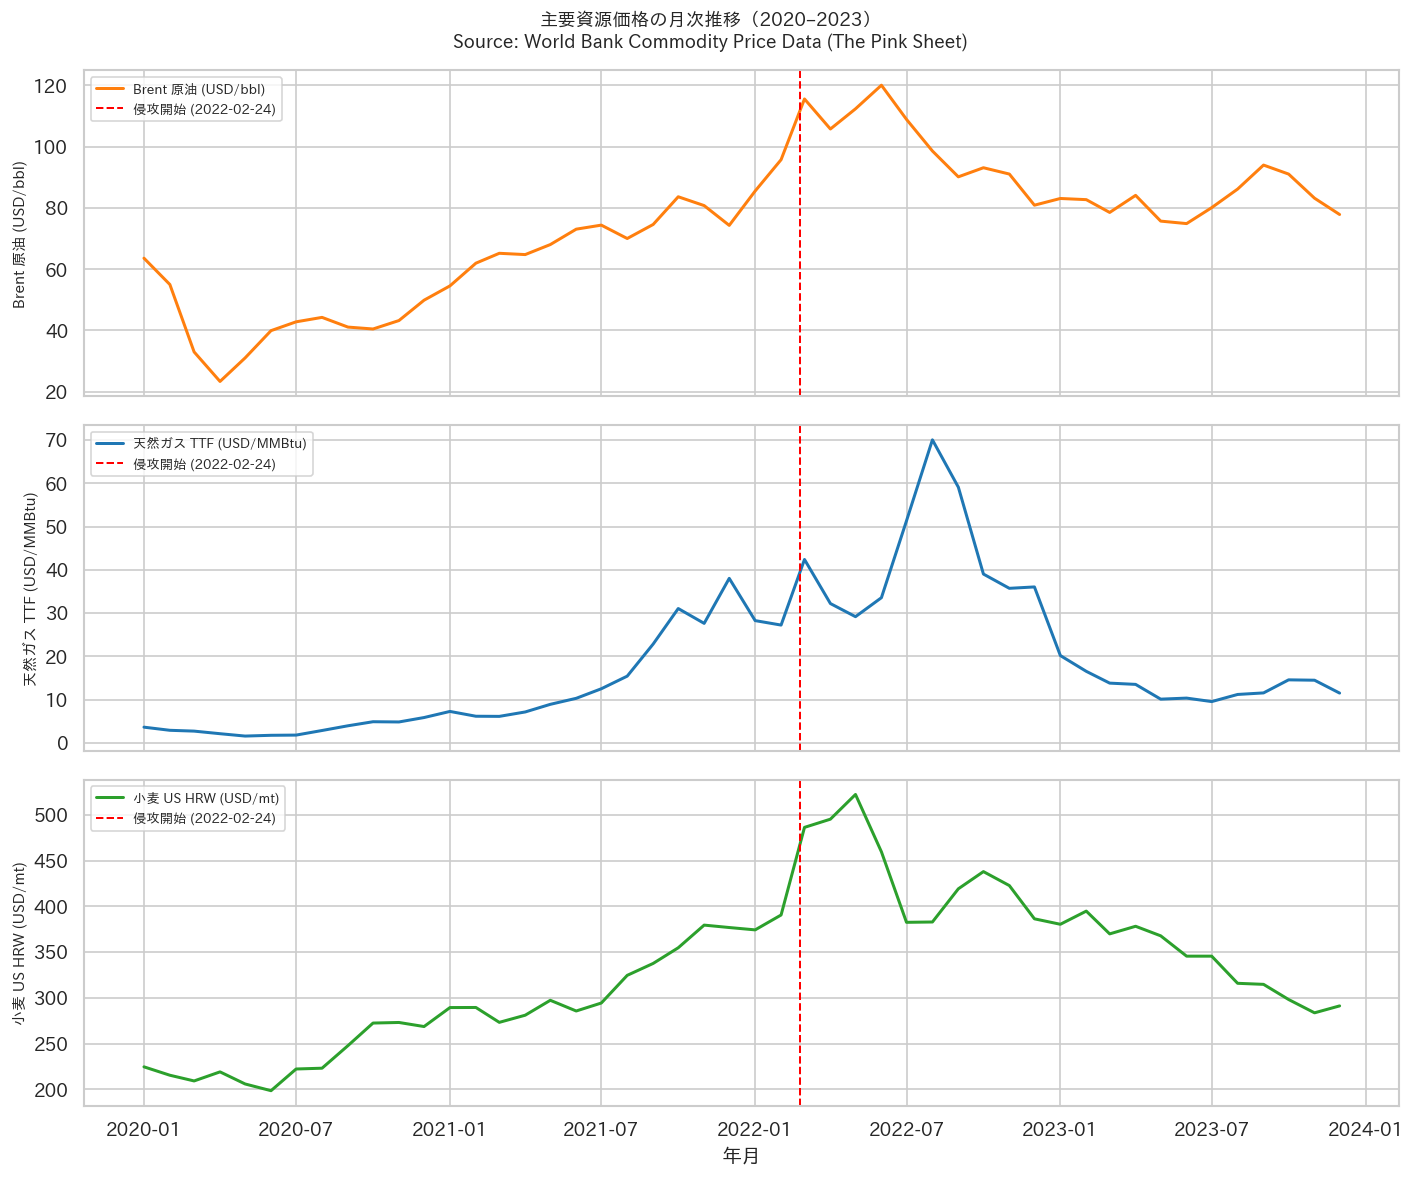

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

commodities = [
    ("brent_usd_bbl",        "Brent 原油 (USD/bbl)",      "tab:orange"),
    ("gas_europe_usd_mmbtu", "天然ガス TTF (USD/MMBtu)",   "tab:blue"),
    ("wheat_hrw_usd_mt",     "小麦 US HRW (USD/mt)",      "tab:green"),
]

dates = [p.to_timestamp() for p in ps["date"]]

for ax, (col, label, color) in zip(axes, commodities):
    ax.plot(dates, ps[col], color=color, linewidth=1.8, label=label)
    ax.axvline(INVASION_DATE, color="red", linestyle="--", linewidth=1.2, label="侵攻開始 (2022-02-24)")
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8, loc="upper left")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

axes[-1].set_xlabel("年月")
fig.suptitle("主要資源価格の月次推移（2020–2023）\nSource: World Bank Commodity Price Data (The Pink Sheet)", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "v1_commodity_prices.png", bbox_inches="tight")
plt.show()

## V2: 侵攻前後の価格変化率（2022-02 を基準 = 100）

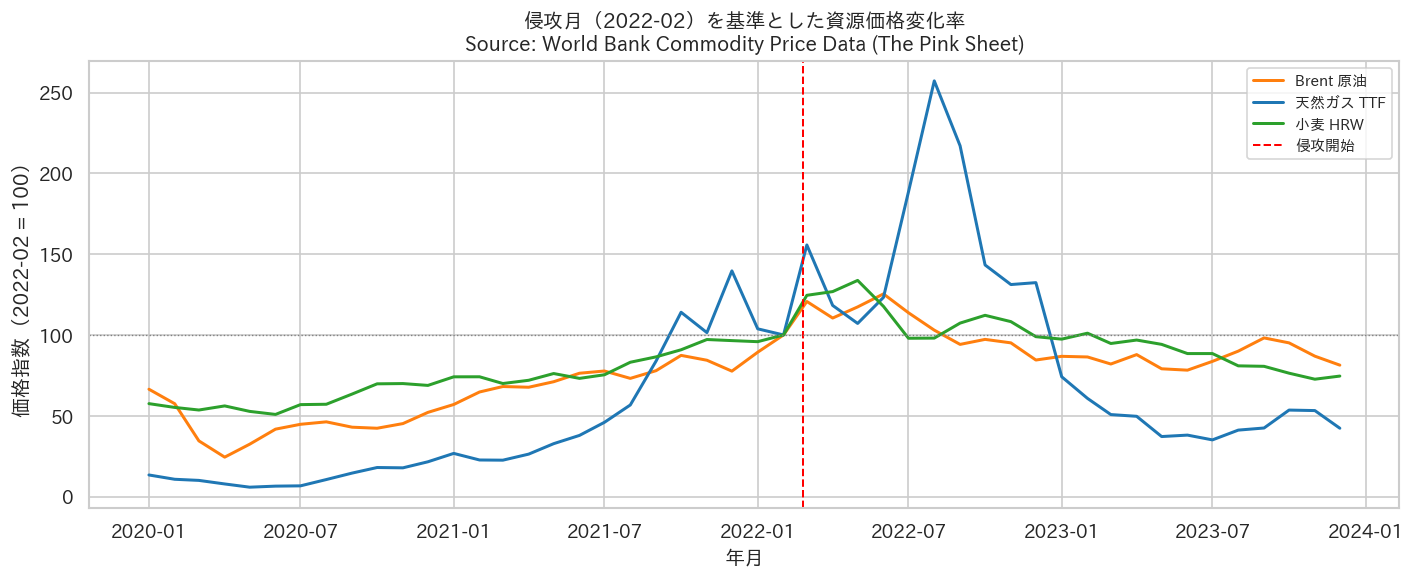

In [7]:
base_row = ps[ps["date"] == INVASION_MONTH].iloc[0]
ps_norm = ps.copy()
for col in ["brent_usd_bbl", "gas_europe_usd_mmbtu", "wheat_hrw_usd_mt"]:
    ps_norm[col] = ps[col] / base_row[col] * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = {"brent_usd_bbl": "tab:orange", "gas_europe_usd_mmbtu": "tab:blue", "wheat_hrw_usd_mt": "tab:green"}
labels = {"brent_usd_bbl": "Brent 原油", "gas_europe_usd_mmbtu": "天然ガス TTF", "wheat_hrw_usd_mt": "小麦 HRW"}

for col in ["brent_usd_bbl", "gas_europe_usd_mmbtu", "wheat_hrw_usd_mt"]:
    ax.plot(dates, ps_norm[col], label=labels[col], color=colors[col], linewidth=1.8)

ax.axvline(INVASION_DATE, color="red", linestyle="--", linewidth=1.2, label="侵攻開始")
ax.axhline(100, color="gray", linestyle=":", linewidth=0.8)
ax.set_ylabel("価格指数（2022-02 = 100）")
ax.set_xlabel("年月")
ax.legend(fontsize=9)
ax.set_title("侵攻月（2022-02）を基準とした資源価格変化率\nSource: World Bank Commodity Price Data (The Pink Sheet)")
fig.tight_layout()
fig.savefig(FIG_DIR / "v2_commodity_indexed.png", bbox_inches="tight")
plt.show()

## V3: 各国 CPI 前年同月比の時系列推移

地域グループ別にサブプロットを分けて比較する。AUS は四半期データを四半期末月に配置（注記あり）。

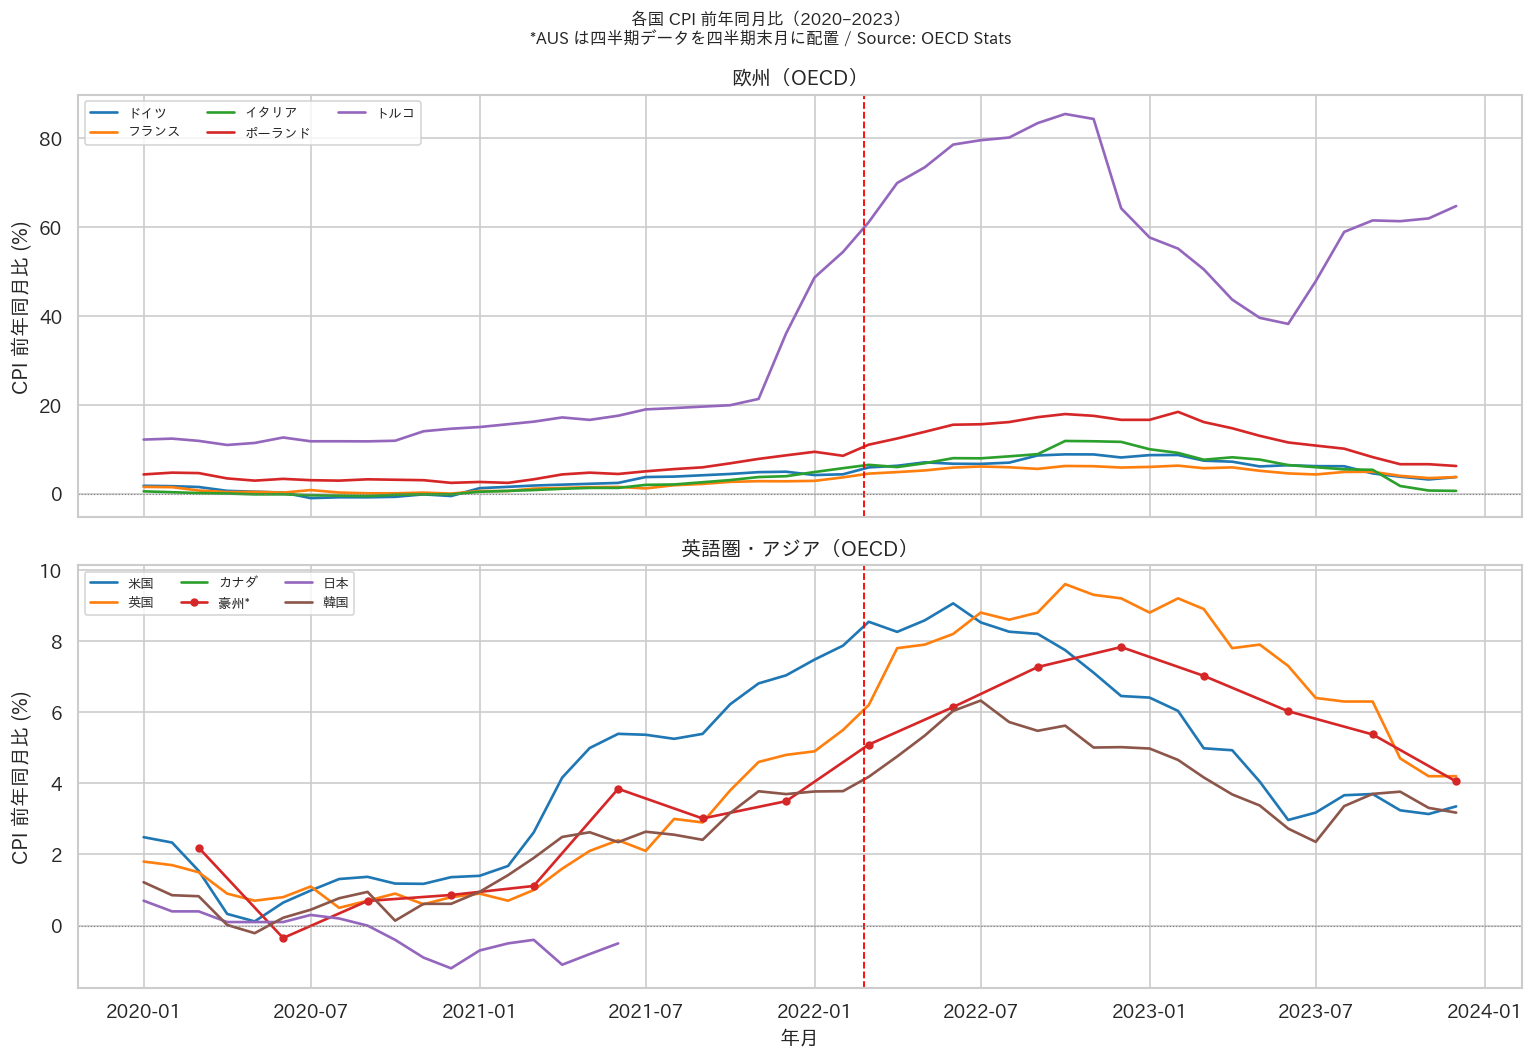

In [8]:
GROUPS = {
    "欧州（OECD）": ["DEU", "FRA", "ITA", "POL", "TUR"],
    "英語圏・アジア（OECD）": ["USA", "GBR", "CAN", "AUS", "JPN", "KOR"],
}
COUNTRY_LABEL = {
    "DEU": "ドイツ", "FRA": "フランス", "ITA": "イタリア",
    "POL": "ポーランド", "TUR": "トルコ",
    "USA": "米国", "GBR": "英国", "CAN": "カナダ",
    "AUS": "豪州*", "JPN": "日本", "KOR": "韓国",
}

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
palette = sns.color_palette("tab10")

for ax, (group_name, countries) in zip(axes, GROUPS.items()):
    for i, c in enumerate(countries):
        df_c = cpi_oecd[cpi_oecd["country"] == c].sort_values("date")
        ax.plot(
            [p.to_timestamp() for p in df_c["date"]],
            df_c["cpi_yoy"],
            label=COUNTRY_LABEL.get(c, c),
            linewidth=1.6,
            color=palette[i],
            marker="o" if c == "AUS" else None,
            markersize=4,
        )
    ax.axvline(INVASION_DATE, color="red", linestyle="--", linewidth=1.1)
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.7)
    ax.set_title(group_name)
    ax.set_ylabel("CPI 前年同月比 (%)")
    ax.legend(fontsize=8, ncol=3, loc="upper left")

axes[-1].set_xlabel("年月")
fig.suptitle("各国 CPI 前年同月比（2020–2023）\n*AUS は四半期データを四半期末月に配置 / Source: OECD Stats", fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "v3_cpi_timeseries_oecd.png", bbox_inches="tight")
plt.show()

## V4: ピーク月（2022-06）における各国 CPI 水準の比較

OECD 月次 + IMF 年次（2022年）を並べる。IMF は年平均値のため横軸に注記する。

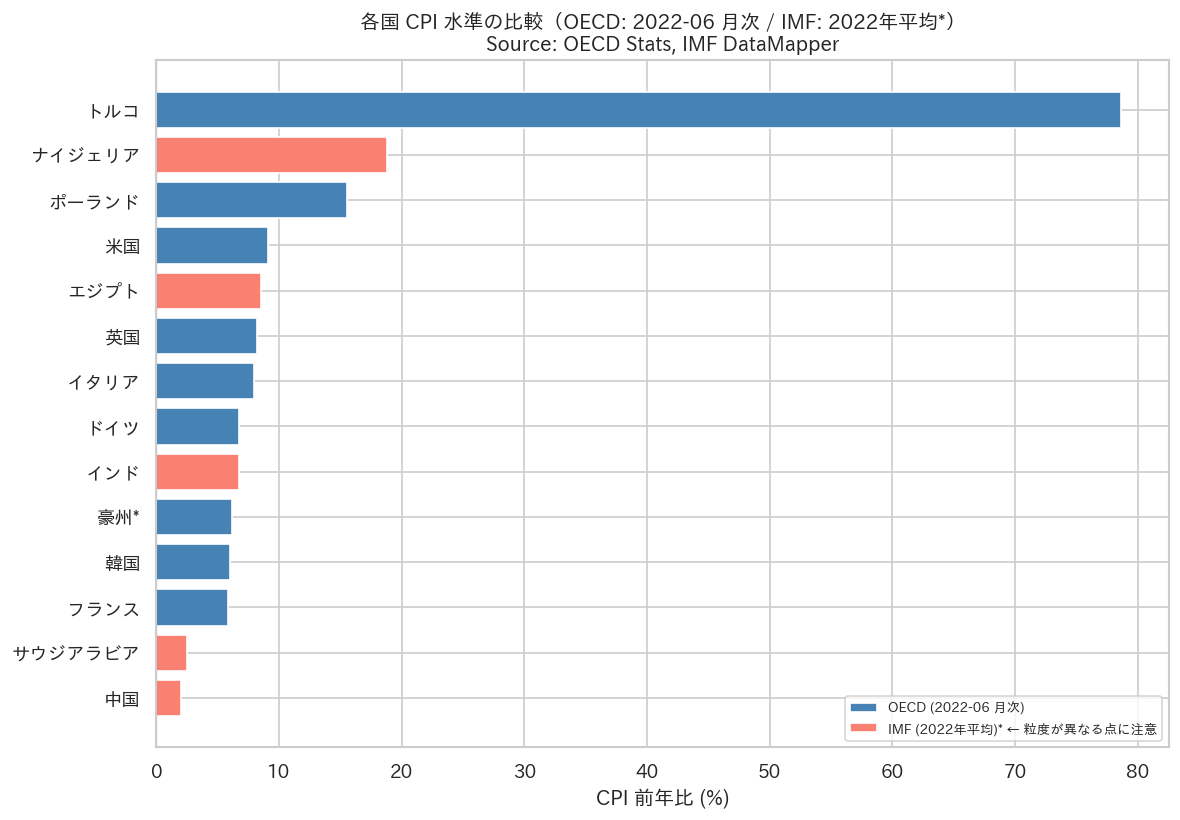

In [9]:
PEAK_MONTH = pd.Period("2022-06", "M")

# OECD 月次
oecd_peak = cpi_oecd[cpi_oecd["date"] == PEAK_MONTH][["country", "cpi_yoy"]].copy()
oecd_peak["source"] = "OECD (2022-06)"

# IMF 年次 2022
imf_peak = imf[imf["year"] == 2022][["country", "cpi_yoy"]].copy()
imf_peak["source"] = "IMF (2022年平均)*"

COUNTRY_LABEL_ALL = {
    **COUNTRY_LABEL,
    "CHN": "中国", "EGY": "エジプト", "IND": "インド",
    "NGA": "ナイジェリア", "SAU": "サウジアラビア",
}
combined = pd.concat([oecd_peak, imf_peak], ignore_index=True)
combined["label"] = combined["country"].map(COUNTRY_LABEL_ALL)
combined = combined.sort_values("cpi_yoy", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = combined["source"].map({"OECD (2022-06)": "steelblue", "IMF (2022年平均)*": "salmon"})
bars = ax.barh(combined["label"], combined["cpi_yoy"], color=colors)
ax.axvline(0, color="gray", linewidth=0.7)
ax.set_xlabel("CPI 前年比 (%)")
ax.set_title("各国 CPI 水準の比較（OECD: 2022-06 月次 / IMF: 2022年平均*）\nSource: OECD Stats, IMF DataMapper")

# 凡例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="OECD (2022-06 月次)"),
    Patch(facecolor="salmon", label="IMF (2022年平均)* ← 粒度が異なる点に注意"),
]
ax.legend(handles=legend_elements, fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "v4_cpi_peak_comparison.png", bbox_inches="tight")
plt.show()

## V5: FAO 食料価格指数の時系列推移（サブ指数含む）

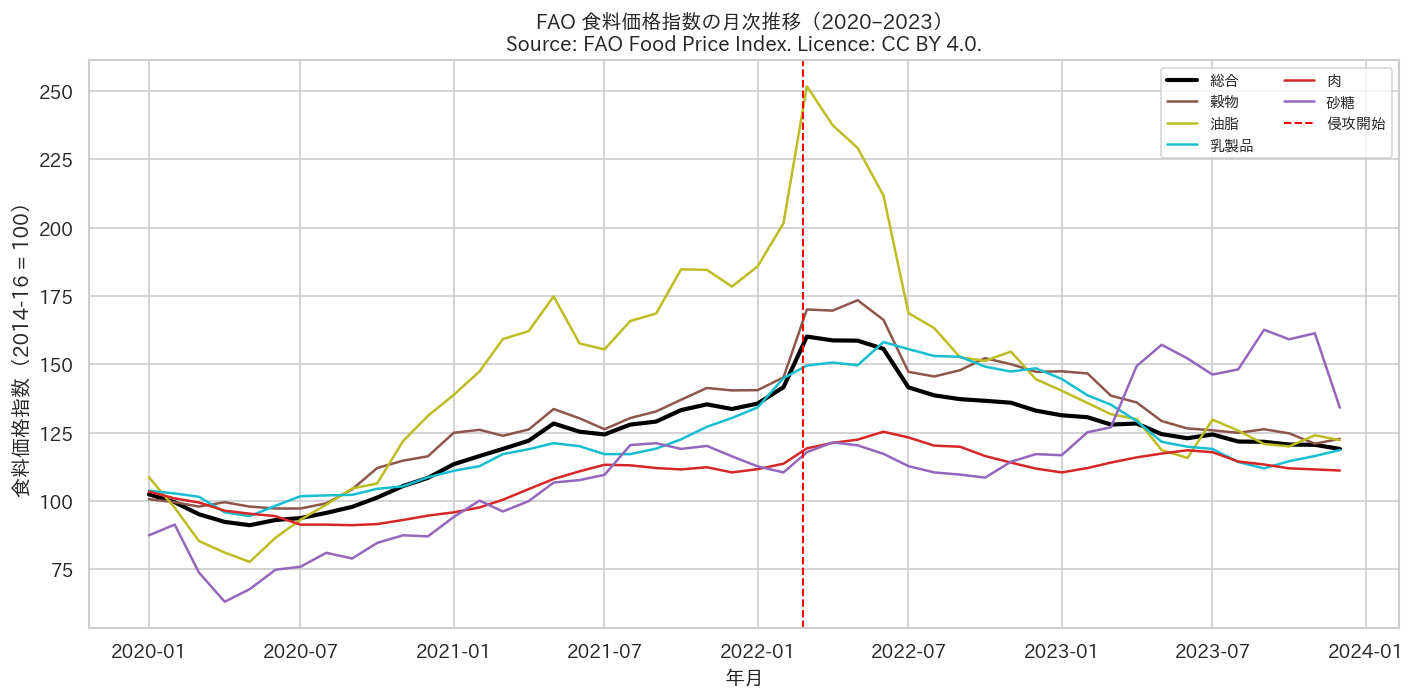

In [10]:
fao_dates = [p.to_timestamp() for p in fao["date"]]

fig, ax = plt.subplots(figsize=(12, 6))
subindices = {
    "food":    ("総合", "black", 2.5),
    "cereals": ("穀物", "tab:brown", 1.5),
    "oils":    ("油脂", "tab:olive", 1.5),
    "dairy":   ("乳製品", "tab:cyan", 1.5),
    "meat":    ("肉", "tab:red", 1.5),
    "sugar":   ("砂糖", "tab:purple", 1.5),
}
for col, (label, color, lw) in subindices.items():
    ax.plot(fao_dates, fao[col], label=label, color=color, linewidth=lw)

ax.axvline(INVASION_DATE, color="red", linestyle="--", linewidth=1.2, label="侵攻開始")
ax.set_ylabel("食料価格指数（2014-16 = 100）")
ax.set_xlabel("年月")
ax.legend(fontsize=9, ncol=2)
ax.set_title("FAO 食料価格指数の月次推移（2020–2023）\nSource: FAO Food Price Index. Licence: CC BY 4.0.")
fig.tight_layout()
fig.savefig(FIG_DIR / "v5_fao_food_price.png", bbox_inches="tight")
plt.show()